In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Superstore.csv')

# Show the first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
!pip install numpy pandas matplotlib seaborn


  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.6-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.0-cp314-cp314-win_amd64.whl.metadata (131 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl (12.7 MB)
Using cached pandas-3.0.6-cp314-cp314-win_amd64.whl (9.8 MB)
Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3

In [2]:
# Convert Order Date and Ship Date to proper datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check for missing values across all columns
print(df.isnull().sum())


ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [3]:
# Convert Order Date and Ship Date to proper datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Check for missing values across all columns
print(df.isnull().sum())


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [4]:
# Remove duplicate rows
df = df.drop_duplicates()

# Create a new feature: Delivery Days
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Preview the new column
df[['Order Date', 'Ship Date', 'Delivery Days']].head()


,Order Date,Ship Date,Delivery Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


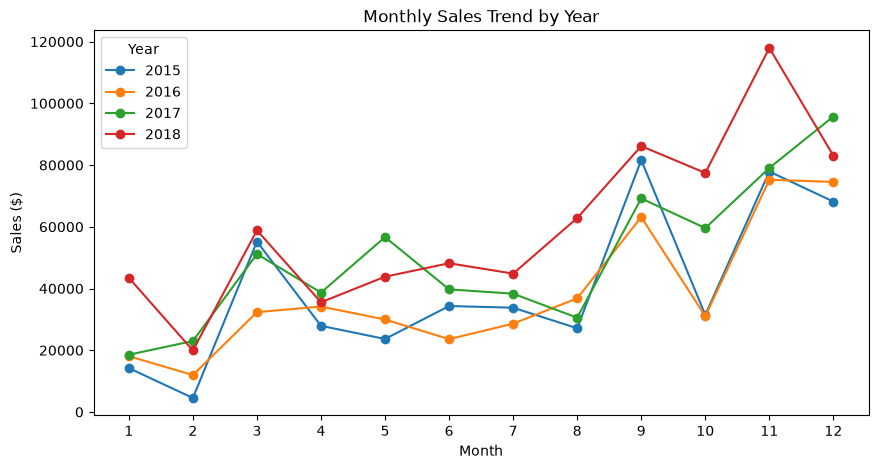

In [5]:
# Extract year and month from Order Date
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

# Group sales by year and month
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()

# Plot the trend
plt.figure(figsize=(10, 5))
for year in monthly_sales['Order Year'].unique():
    data = monthly_sales[monthly_sales['Order Year'] == year]
    plt.plot(data['Order Month'], data['Sales'], marker='o', label=str(year))

plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.show()

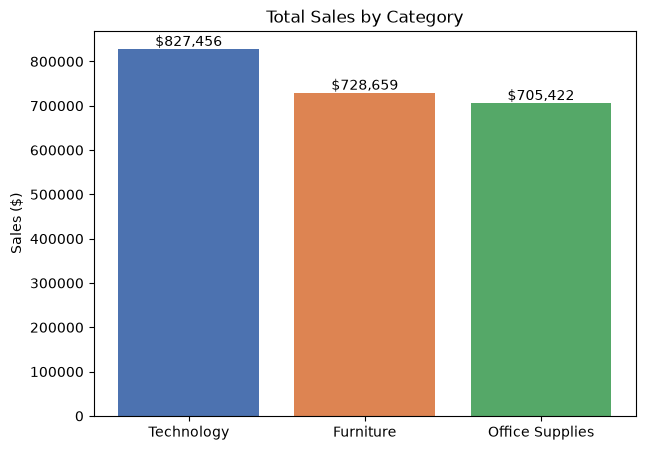

In [6]:
# Total sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
bars = plt.bar(category_sales.index, category_sales.values, color=['#4C72B0', '#DD8452', '#55A868'])

plt.title('Total Sales by Category')
plt.ylabel('Sales ($)')

# Add dollar labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'${height:,.0f}', ha='center', va='bottom')

plt.show()


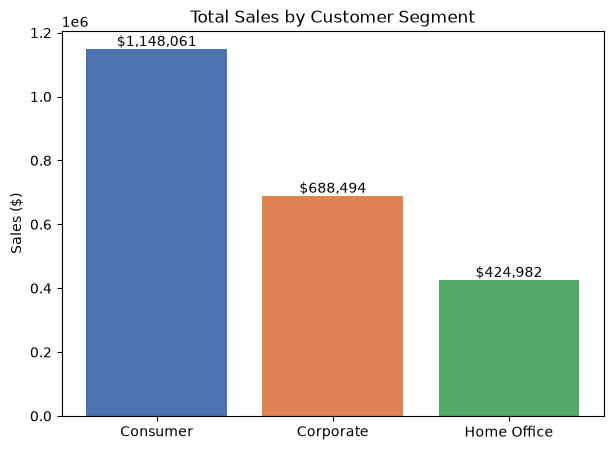

In [7]:
# Total sales by customer segment
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
bars = plt.bar(segment_sales.index, segment_sales.values, color=['#4C72B0', '#DD8452', '#55A868'])

plt.title('Total Sales by Customer Segment')
plt.ylabel('Sales ($)')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'${height:,.0f}', ha='center', va='bottom')

plt.show()


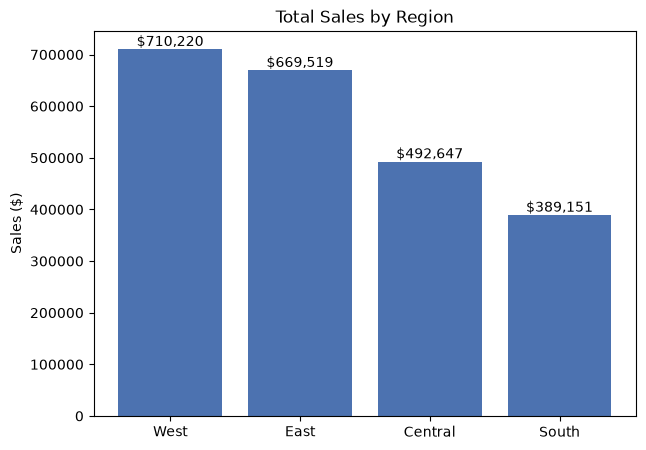

In [8]:
# Total sales by region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
bars = plt.bar(region_sales.index, region_sales.values, color='#4C72B0')

plt.title('Total Sales by Region')
plt.ylabel('Sales ($)')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'${height:,.0f}', ha='center', va='bottom')

plt.show()

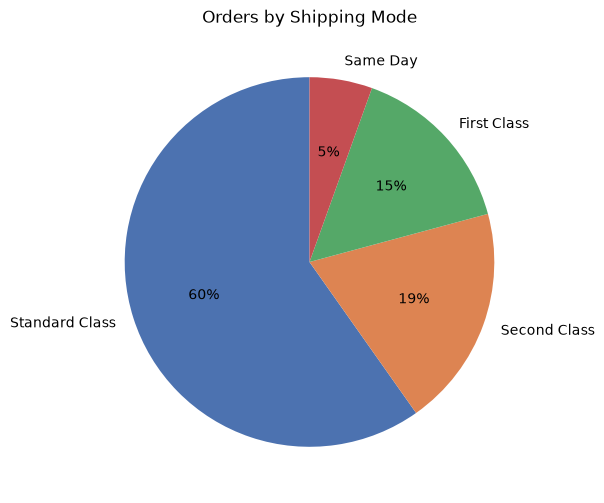

Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64


In [9]:
# Orders by shipping mode
shipping_counts = df['Ship Mode'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(shipping_counts.values, labels=shipping_counts.index, autopct='%1.0f%%', startangle=90,
        colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

plt.title('Orders by Shipping Mode')
plt.show()

print(shipping_counts)


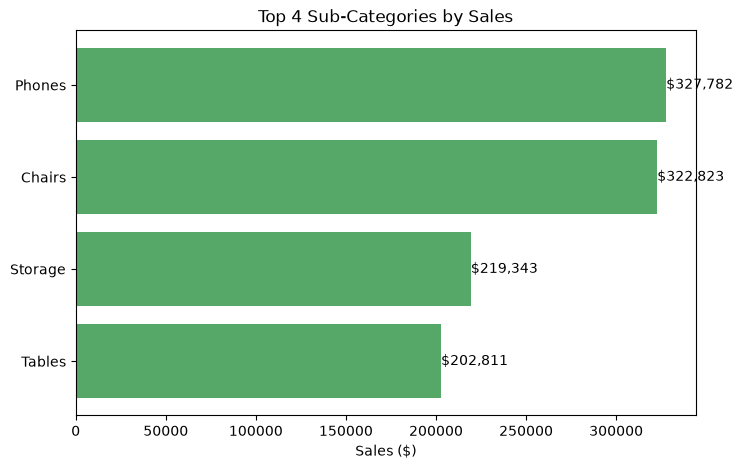

In [10]:
# Top 4 sub-categories by sales
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(4)
subcat_sales = subcat_sales.sort_values()  # smallest to largest, so the chart reads top-to-bottom correctly

plt.figure(figsize=(8, 5))
bars = plt.barh(subcat_sales.index, subcat_sales.values, color='#55A868')

plt.title('Top 4 Sub-Categories by Sales')
plt.xlabel('Sales ($)')

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'${width:,.0f}', ha='left', va='center')

plt.show()
